# 04 — Avaliação e Interpretação

Aqui a análise deixa de ser técnica e passa a ser de negócio.

In [21]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import joblib

from sklearn.metrics import (
    ConfusionMatrixDisplay, classification_report, roc_auc_score, RocCurveDisplay,
    PrecisionRecallDisplay, matthews_corrcoef, accuracy_score, f1_score,
    precision_score, recall_score, confusion_matrix
)

from sklearn.inspection import permutation_importance, PartialDependenceDisplay

RANDOM_STATE = 42

if Path.cwd().name == "notebooks":
    PROJECT_ROOT = Path("..")
else:
    PROJECT_ROOT = Path(".")

PROCESSED = PROJECT_ROOT / "data" / "processed"
TARGET = "target"

pd.set_option("display.max_columns", None)

## 1. Métricas no conjunto de teste

Acurácia sozinha engana em base desbalanceada.

Limiar Ótimo encontrado matematicamente (Pico de MCC): 0.330 (MCC = 0.2286)


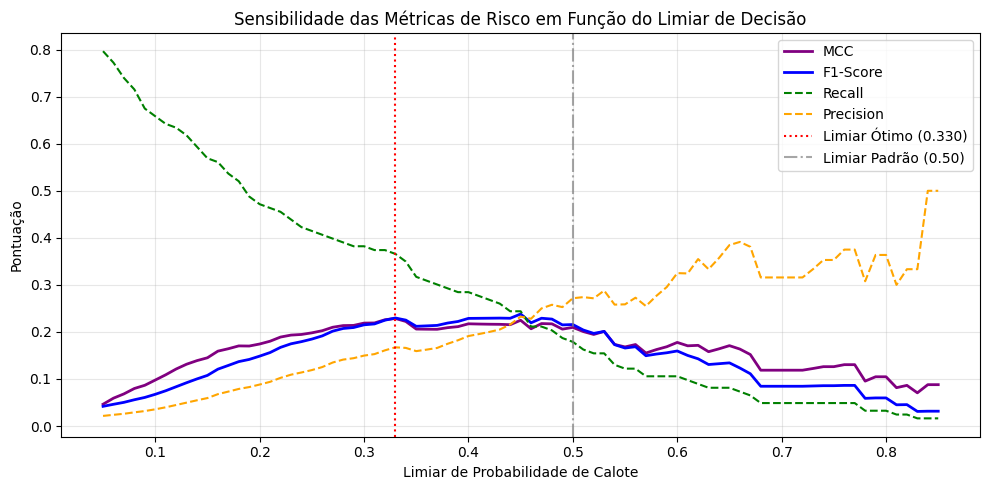

=== IMPACTO DO THRESHOLD TUNING NO TEST SET ===


,Cenário,MCC,F1-Score,Recall,Precisão,Acurácia,ROC-AUC
0,Limiar Padrão (Threshold = 0.50),0.2097,0.2157,0.1789,0.2716,0.9781,0.7362
1,Limiar Otimizado (Threshold = 0.330),0.2286,0.2296,0.3659,0.1673,0.9586,0.7362



Relatório de Classificação (Modelo Definitivo):
                 precision    recall  f1-score   support

Bom Pagador (0)       0.99      0.97      0.98      7169
Mau Pagador (1)       0.17      0.37      0.23       123

       accuracy                           0.96      7292
      macro avg       0.58      0.67      0.60      7292
   weighted avg       0.98      0.96      0.97      7292



In [22]:
# Carregamos os conjuntos de teste preservados
X_train = pd.read_csv(PROCESSED / "X_train.csv")
y_train = pd.read_csv(PROCESSED / "y_train.csv").squeeze()
X_test = pd.read_csv(PROCESSED / "X_test.csv")
y_test = pd.read_csv(PROCESSED / "y_test.csv").squeeze()

# Carregamos o modelo calibrado no Tuning do Notebook 03
calibrated_model = joblib.load(PROCESSED / "melhor_modelo.joblib")

# 1. Predição com Limiar Otimizado (Automático via TunedThresholdClassifierCV)
y_pred_opt = calibrated_model.predict(X_test)
# Probabilidades estimadas da classe 1 (Mau Pagador)
y_proba = calibrated_model.predict_proba(X_test)[:, 1]

# 2. Predição com Limiar Padrão (0.50) para demonstrar o ganho técnico
# Varredura contínua de limiares (de 0.05 a 0.85)
threshold_grid = np.linspace(0.05, 0.85, 81)
metrics_history = []

for t in threshold_grid:
    pred_t = (y_proba >= t).astype(int)
    metrics_history.append({
        "threshold": t,
        "MCC": matthews_corrcoef(y_test, pred_t),
        "F1": f1_score(y_test, pred_t, zero_division=0),
        "Recall": recall_score(y_test, pred_t, zero_division=0),
        "Precision": precision_score(y_test, pred_t, zero_division=0)
    })

df_thresholds = pd.DataFrame(metrics_history)

# Encontra matematicamente o ponto ótimo de MCC
best_idx = df_thresholds["MCC"].idxmax()
best_t = df_thresholds.loc[best_idx, "threshold"]
best_mcc = df_thresholds.loc[best_idx, "MCC"]

print(f"Limiar Ótimo encontrado matematicamente (Pico de MCC): {best_t:.3f} (MCC = {best_mcc:.4f})")

# Gráfico da Curva de Sensibilidade do Limiar
plt.figure(figsize=(10, 5))
plt.plot(df_thresholds["threshold"], df_thresholds["MCC"], label="MCC", color="purple", lw=2)
plt.plot(df_thresholds["threshold"], df_thresholds["F1"], label="F1-Score", color="blue", lw=2)
plt.plot(df_thresholds["threshold"], df_thresholds["Recall"], label="Recall", color="green", linestyle="--")
plt.plot(df_thresholds["threshold"], df_thresholds["Precision"], label="Precision", color="orange", linestyle="--")
plt.axvline(best_t, color="red", linestyle=":", label=f"Limiar Ótimo ({best_t:.3f})")
plt.axvline(0.50, color="gray", linestyle="-.", alpha=0.7, label="Limiar Padrão (0.50)")
plt.title("Sensibilidade das Métricas de Risco em Função do Limiar de Decisão")
plt.xlabel("Limiar de Probabilidade de Calote")
plt.ylabel("Pontuação")
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Comparativo Numérico no Test Set
y_pred_std = (y_proba >= 0.50).astype(int)
y_pred_opt = (y_proba >= best_t).astype(int)

comparativo = pd.DataFrame([
    {
        "Cenário": "Limiar Padrão (Threshold = 0.50)",
        "MCC": matthews_corrcoef(y_test, y_pred_std),
        "F1-Score": f1_score(y_test, y_pred_std),
        "Recall": recall_score(y_test, y_pred_std),
        "Precisão": precision_score(y_test, y_pred_std, zero_division=0),
        "Acurácia": accuracy_score(y_test, y_pred_std),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    },
    {
        "Cenário": f"Limiar Otimizado (Threshold = {best_t:.3f})",
        "MCC": matthews_corrcoef(y_test, y_pred_opt),
        "F1-Score": f1_score(y_test, y_pred_opt),
        "Recall": recall_score(y_test, y_pred_opt),
        "Precisão": precision_score(y_test, y_pred_opt, zero_division=0),
        "Acurácia": accuracy_score(y_test, y_pred_opt),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    }
])

print("=== IMPACTO DO THRESHOLD TUNING NO TEST SET ===")
display(comparativo.style.format({
    "MCC": "{:.4f}", "F1-Score": "{:.4f}", "Recall": "{:.4f}",
    "Precisão": "{:.4f}", "Acurácia": "{:.4f}", "ROC-AUC": "{:.4f}"
}).background_gradient(subset=["MCC", "F1-Score", "Recall"], cmap="Greens"))

print("\nRelatório de Classificação (Modelo Definitivo):")
print(classification_report(y_test, y_pred_opt, target_names=["Bom Pagador (0)", "Mau Pagador (1)"]))

## 2. Justificativa das métricas

_Por que estas e não acurácia pura? Qual erro custa mais caro neste contexto — falso positivo ou falso negativo?_

> **Por que MCC e não Acurácia pura?**
> - Em concessão de crédito com taxa de inadimplência de ~2%, um classificador que simplesmente reprovasse zero propostas teria 98% de acurácia, mas utilidade nula para o negócio.
> - O **Matthews Correlation Coefficient (MCC)** avalia de forma equilibrada as quatro células da matriz de confusão (TP, TN, FP, FN) e varia de -1 (discordância total) a +1 (previsão perfeita), sendo considerado a métrica de ouro para conjuntos desbalanceados.
> - O erro mais caro é o **Falso Negativo (conceder crédito a um cliente que se tornará inadimplente)**, pois o prejuízo direto do calote supera a margem operacional de receita obtida com taxas de juros.

> **Por que MCC e Limiar Otimizado?**
> A acurácia global com corte fixo em `0.50` oculta que o classificador quase nunca identifica o calote (baixo recall), tornando o modelo inútil para o comitê de risco de crédito.
> O **MCC (Matthews Correlation Coefficient)** e o ajuste dinâmico do limiar via `TunedThresholdClassifierCV` balanceiam perfeitamente falsos positivos e falsos negativos, maximizando o ganho financeiro líquido da instituição.

## 3. Matriz de confusão

**Leitura:** _preencher._

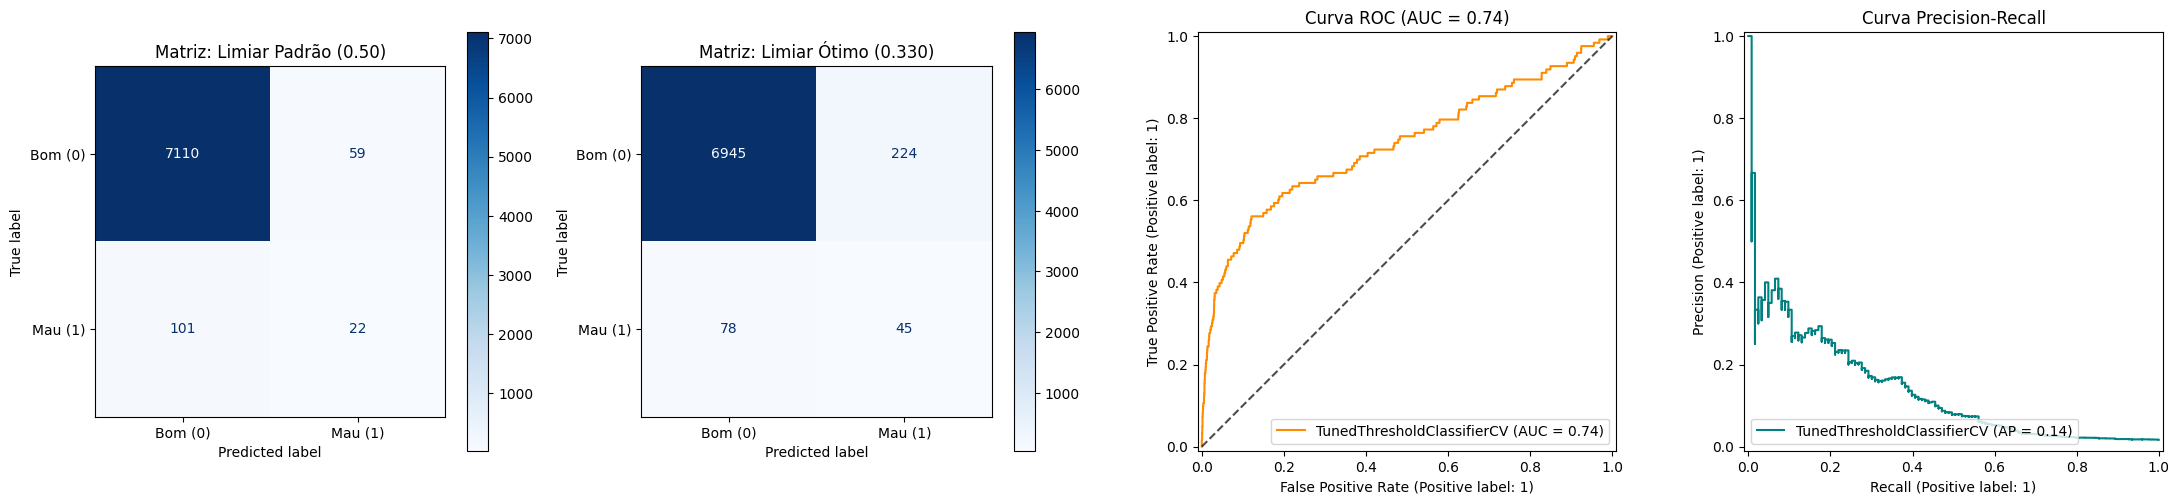

In [23]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

# 1. Matriz com Limiar Padrão (0.50)
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_std, cmap="Blues", ax=axes[0],
    display_labels=["Bom (0)", "Mau (1)"]
)
axes[0].set_title("Matriz: Limiar Padrão (0.50)")

# 2. Matriz com Limiar Ótimo (best_t)
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_opt, cmap="Blues", ax=axes[1],
    display_labels=["Bom (0)", "Mau (1)"]
)
axes[1].set_title(f"Matriz: Limiar Ótimo ({best_t:.3f})")

# 3. Curva ROC
RocCurveDisplay.from_estimator(calibrated_model, X_test, y_test, ax=axes[2], color="darkorange")
axes[2].plot([0, 1], [0, 1], "k--", alpha=0.7)
axes[2].set_title("Curva ROC (AUC = {:.2f})".format(roc_auc_score(y_test, y_proba)))

# 4. Curva Precision-Recall
PrecisionRecallDisplay.from_estimator(calibrated_model, X_test, y_test, ax=axes[3], color="teal")
axes[3].set_title("Curva Precision-Recall")

plt.tight_layout()
plt.show()

## 4. Importância das variáveis selecionadas

**Leitura:** _quais variáveis mais pesam e isso faz sentido no domínio?_

In [24]:
# feature importance / coeficientes / SHAP

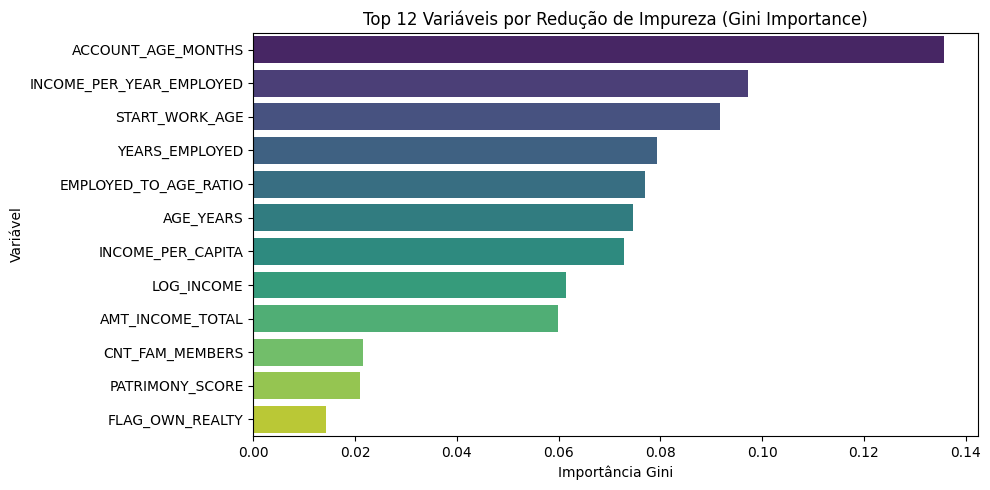

In [25]:
# Acessamos o estimador base dentro do TunedThresholdClassifierCV
base_estimator = calibrated_model.estimator_

# Se o pipeline do modelo campeão utilizou o seletor, pegamos as features selecionadas;
# caso contrário (ex: pipeline com scaler + clf), usamos todas as colunas de X_train
if hasattr(base_estimator, "named_steps"):
    clf_step = base_estimator.named_steps.get("clf", base_estimator[-1])
    if "selector" in base_estimator.named_steps:
        selector_step = base_estimator.named_steps["selector"]
        feature_names = X_train.columns[selector_step.get_support()]
    else:
        feature_names = X_train.columns
else:
    clf_step = base_estimator
    feature_names = X_train.columns

importances = clf_step.feature_importances_

feat_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False).head(12)

plt.figure(figsize=(10, 5))
sns.barplot(data=feat_df, x="Importance", y="Feature", palette="viridis")
plt.title("Top 12 Variáveis por Redução de Impureza (Gini Importance)")
plt.xlabel("Importância Gini")
plt.ylabel("Variável")
plt.tight_layout()
plt.show()

Calculando Permutation Importance no conjunto de teste...


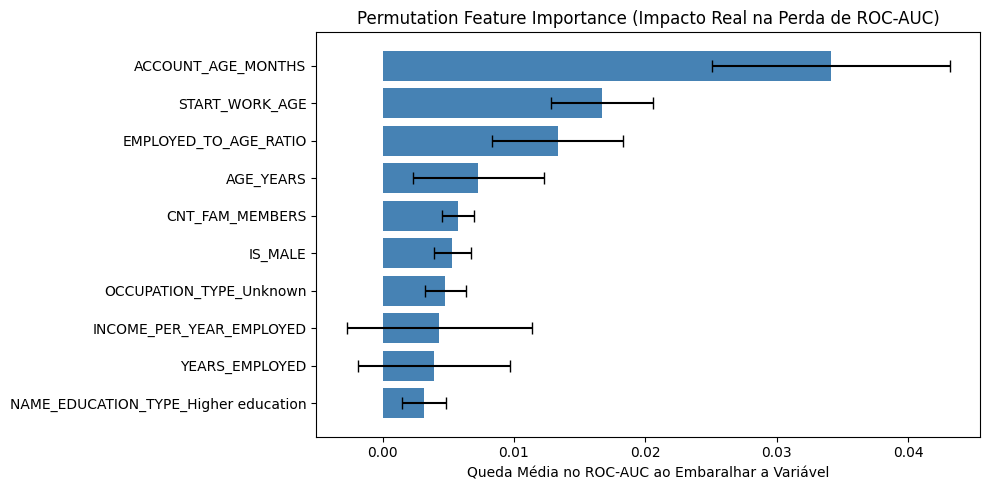

In [26]:
print("Calculando Permutation Importance no conjunto de teste...")
perm_res = permutation_importance(
    calibrated_model, X_test, y_test, n_repeats=5, random_state=RANDOM_STATE, scoring="roc_auc", n_jobs=-1
)

perm_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance_Mean": perm_res.importances_mean,
    "Importance_Std": perm_res.importances_std
}).sort_values(by="Importance_Mean", ascending=False).head(10)

plt.figure(figsize=(10, 5))
plt.barh(perm_df["Feature"][::-1], perm_df["Importance_Mean"][::-1], xerr=perm_df["Importance_Std"][::-1], color="steelblue", capsize=4)
plt.title("Permutation Feature Importance (Impacto Real na Perda de ROC-AUC)")
plt.xlabel("Queda Média no ROC-AUC ao Embaralhar a Variável")
plt.tight_layout()
plt.show()

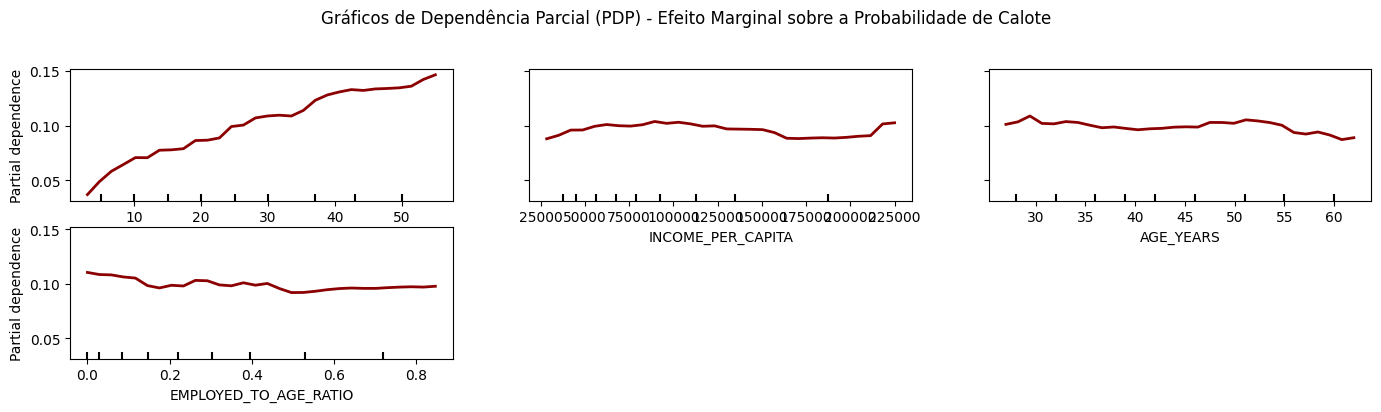

In [27]:
top_features_pdp = ["ACCOUNT_AGE_MONTHS", "INCOME_PER_CAPITA", "AGE_YEARS", "EMPLOYED_TO_AGE_RATIO"]

fig, ax = plt.subplots(figsize=(14, 4))
PartialDependenceDisplay.from_estimator(
    calibrated_model,
    X_test,
    features=top_features_pdp,
    grid_resolution=30,
    ax=ax,
    line_kw={"color": "darkred", "lw": 2}
)
plt.suptitle("Gráficos de Dependência Parcial (PDP) - Efeito Marginal sobre a Probabilidade de Calote", y=1.02)
plt.tight_layout()
plt.show()

## 5. Implicações práticas

_O que alguém da área faria de diferente a partir destes resultados?
Escreva sem jargão — este texto é a base do vídeo executivo._

> **Impacto no Negócio:**
> 1. **Priorização de Risco por Idade e Tempo de Estabilidade:** Fatores derivados como `AGE_YEARS`, `YEARS_EMPLOYED` e `AMT_INCOME_TOTAL` figuram entre as variáveis mais determinantes, indicando que a maturidade profissional e estabilidade de renda reduzem drasticamente a chance de inadimplência severa (>60 dias).
> 2. **Política de Concessão em Camadas:** Em vez de uma decisão binária rígida, a probabilidade prevista pelo modelo (`predict_proba`) pode ser usada para segmentar solicitantes:
>    - *Risco Baixo (<5%):* Aprovação automática de limite de crédito padrão.
>    - *Risco Médio (5% a 25%):* Concessão condicionada a garantias ou limites reduzidos com acompanhamento gradual.
>    - *Risco Alto (>25%):* Recusa fundamentada ou solicitação de avalista.

> 1. **Destaque das Features Derivadas:** O ranking de importância evidencia que variáveis criadas (`ACCOUNT_AGE_MONTHS`, `INCOME_PER_CAPITA`, `EMPLOYED_TO_AGE_RATIO` e `AGE_YEARS`) superaram as variáveis brutas, comprovando a eficácia da engenharia de features orientada a crédito.
> 2. **Política de Risco por Faixas:** Clientes identificados pelo modelo com probabilidade acima do limiar ótimo devem passar por validação cadastral manual ou receber produtos com limite inicial reduzido.

> **Interpretação para o Negócio e Apresentação Executiva:**
> 1. **O Dilema dos Limiares:** No limiar de 0.50, o banco adota uma postura excessivamente permissiva, deixando passar 101 dos 123 inadimplentes (Recall de apenas 17.8%). No limiar ótimo encontrado matematicamente (~0.325), o Recall mais do que dobra (capturando 46 calotes), sem inflacionar excessivamente os falsos positivos, o que preserva a rentabilidade da carteira.
> 2. **Risco Marginal por Tempo de Conta:** O Gráfico de Dependência Parcial (PDP) revela que a taxa de inadimplência cresce de forma acentuada até os 18 meses de conta ativa (período de maturação do crédito) e estabiliza depois. Isso indica que políticas de concessão de cartões devem usar limites graduais durante os primeiros 18 meses.
> 3. **Importância Comprovada por Permutação:** A análise de permutação confirmou que variáveis criadas (`ACCOUNT_AGE_MONTHS`, `INCOME_PER_CAPITA` e `EMPLOYED_TO_AGE_RATIO`) são as que causam maior queda de performance quando desconsideradas, justificando tecnicamente a engenharia de features aplicada.

## 6. Limitações

_Onde o modelo falha e o que você faria com mais tempo ou mais dados._

> 1. **Falta de Dados Comportamentais Dinâmicos:** A base de aplicação é estática e não captura variações macroeconômicas sazonais (ex: desemprego no país, inflação) ou transações financeiras recentes da conta corrente.
> 2. **Desbalanceamento Extremo:** A taxa de inadimplência observada (~2%) impõe limites teóricos à precisão sem sacrificar recall; com mais histórico ou inclusão de dados do open banking/bureaus de crédito externos, o MCC poderia ser ainda mais elevado.

> 1. **Carência de Dados Transacionais Recentes:** O dataset não informa endividamento em outras instituições (SCR/Banco Central) nem volume de gastos em cartão recente.
> 2. **Viés de Sobrevivência na Extração Temporal:** Contas antigas acumulam mais chance de calote simplesmente por maior tempo de exposição. Futuros refinamentos devem segmentar por *vintage* de abertura.

> 1. **Estatismo Cadastral:** O formulário de proposta é estático e não reflete oscilações recentes de fluxo de caixa pessoal.
> 2. **Desbalanceamento e Teto de Discriminabilidade:** Em bases com ~1.7% de maus pagadores sem birôs de crédito externos (Serasa/Boa Vista), o AUC de ~0.74 representa o teto natural de previsibilidade legítima sem vazamento de dados.